In [177]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [178]:
!pip install snowflake_connector_python pandas scikit-learn


In [179]:
import snowflake.connector
import pandas as pd

In [180]:
con = snowflake.connector.connect(
    user = "Alaguraja",
    password = "Alagurajakannan@787",
    account = "DXMKEOQ-ON75318",
    database = "insurance",
    schema = "PUBLIC",
    warehouse = "COMPUTE_WH"
)

In [181]:
query = "select * from insurancedb"

In [182]:
df = pd.read_sql(query, con)

/tmp/ipykernel_1441/1914986641.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con)


In [183]:
df

,MONTHS_AS_CUSTOMER,AGE,POLICY_NUMBER,POLICY_BIND_DATE,POLICY_STATE,POLICY_CSL,POLICY_DEDUCTABLE,POLICY_ANNUAL_PREMIUM,UMBRELLA_LIMIT,INSURED_ZIP,...,POLICE_REPORT_AVAILABLE,TOTAL_CLAIM_AMOUNT,INJURY_CLAIM,PROPERTY_CLAIM,VEHICLE_CLAIM,AUTO_MAKE,AUTO_MODEL,AUTO_YEAR,FRAUD_REPORTED,_C39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,True,None
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,True,None
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,False,None
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,True,None
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,False,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,941851,1991-07-16,OH,500/1000,1000,1310.80,0,431289,...,?,87200,17440,8720,61040,Honda,Accord,2006,False,None
996,285,41,186934,2014-01-05,IL,100/300,1000,1436.79,0,608177,...,?,108480,18080,18080,72320,Volkswagen,Passat,2015,False,None
997,130,34,918516,2003-02-17,OH,250/500,500,1383.49,3000000,442797,...,YES,67500,7500,7500,52500,Suburu,Impreza,1996,False,None
998,458,62,533940,2011-11-18,IL,500/1000,2000,1356.92,5000000,441714,...,YES,46980,5220,5220,36540,Audi,A5,1998,False,None


##**Exploratory Data Analysis**

In [184]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   MONTHS_AS_CUSTOMER           1000 non-null   int64  
 1   AGE                          1000 non-null   int64  
 2   POLICY_NUMBER                1000 non-null   int64  
 3   POLICY_BIND_DATE             1000 non-null   object 
 4   POLICY_STATE                 1000 non-null   object 
 5   POLICY_CSL                   1000 non-null   object 
 6   POLICY_DEDUCTABLE            1000 non-null   int64  
 7   POLICY_ANNUAL_PREMIUM        1000 non-null   float64
 8   UMBRELLA_LIMIT               1000 non-null   int64  
 9   INSURED_ZIP                  1000 non-null   int64  
 10  INSURED_SEX                  1000 non-null   object 
 11  INSURED_EDUCATION_LEVEL      1000 non-null   object 
 12  INSURED_OCCUPATION           1000 non-null   object 
 13  INSURED_HOBBIES    

In [185]:
df.describe()

,MONTHS_AS_CUSTOMER,AGE,POLICY_NUMBER,POLICY_DEDUCTABLE,POLICY_ANNUAL_PREMIUM,UMBRELLA_LIMIT,INSURED_ZIP,CAPITAL_GAINS,CAPITAL_LOSS,INCIDENT_HOUR_OF_THE_DAY,NUMBER_OF_VEHICLES_INVOLVED,BODILY_INJURIES,WITNESSES,TOTAL_CLAIM_AMOUNT,INJURY_CLAIM,PROPERTY_CLAIM,VEHICLE_CLAIM,AUTO_YEAR
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000


In [186]:
df.isna().sum()

,0
MONTHS_AS_CUSTOMER,0
AGE,0
POLICY_NUMBER,0
POLICY_BIND_DATE,0
POLICY_STATE,0
POLICY_CSL,0
POLICY_DEDUCTABLE,0
POLICY_ANNUAL_PREMIUM,0
UMBRELLA_LIMIT,0
INSURED_ZIP,0


In [187]:
df.drop(columns = ["_C39"], inplace = True)

In [188]:
df.columns

Index(['MONTHS_AS_CUSTOMER', 'AGE', 'POLICY_NUMBER', 'POLICY_BIND_DATE',
       'POLICY_STATE', 'POLICY_CSL', 'POLICY_DEDUCTABLE',
       'POLICY_ANNUAL_PREMIUM', 'UMBRELLA_LIMIT', 'INSURED_ZIP', 'INSURED_SEX',
       'INSURED_EDUCATION_LEVEL', 'INSURED_OCCUPATION', 'INSURED_HOBBIES',
       'INSURED_RELATIONSHIP', 'CAPITAL_GAINS', 'CAPITAL_LOSS',
       'INCIDENT_DATE', 'INCIDENT_TYPE', 'COLLISION_TYPE', 'INCIDENT_SEVERITY',
       'AUTHORITIES_CONTACTED', 'INCIDENT_STATE', 'INCIDENT_CITY',
       'INCIDENT_LOCATION', 'INCIDENT_HOUR_OF_THE_DAY',
       'NUMBER_OF_VEHICLES_INVOLVED', 'PROPERTY_DAMAGE', 'BODILY_INJURIES',
       'WITNESSES', 'POLICE_REPORT_AVAILABLE', 'TOTAL_CLAIM_AMOUNT',
       'INJURY_CLAIM', 'PROPERTY_CLAIM', 'VEHICLE_CLAIM', 'AUTO_MAKE',
       'AUTO_MODEL', 'AUTO_YEAR', 'FRAUD_REPORTED'],
      dtype='object')

In [189]:
df.shape

(1000, 39)

In [190]:
df.duplicated().sum()

np.int64(0)

##**Data preprocessing**

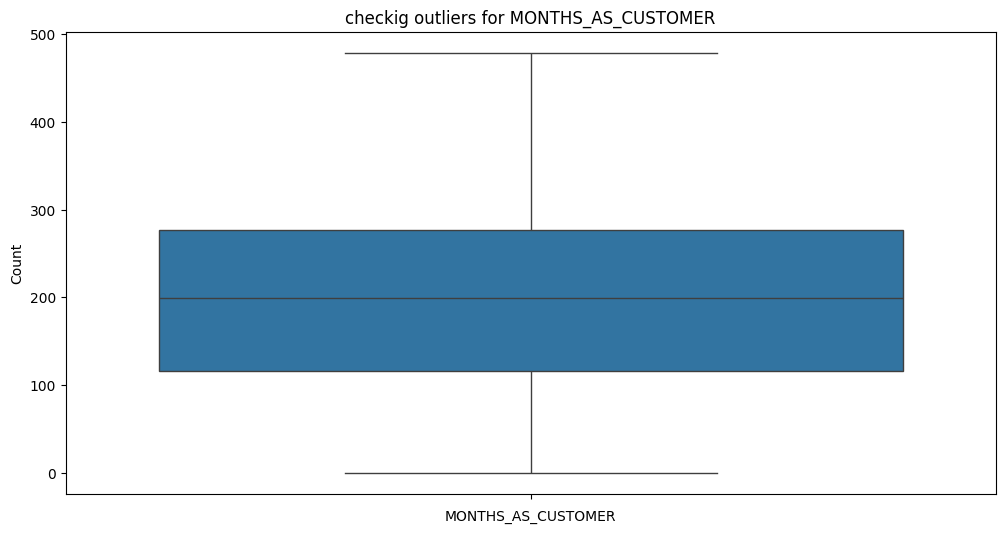

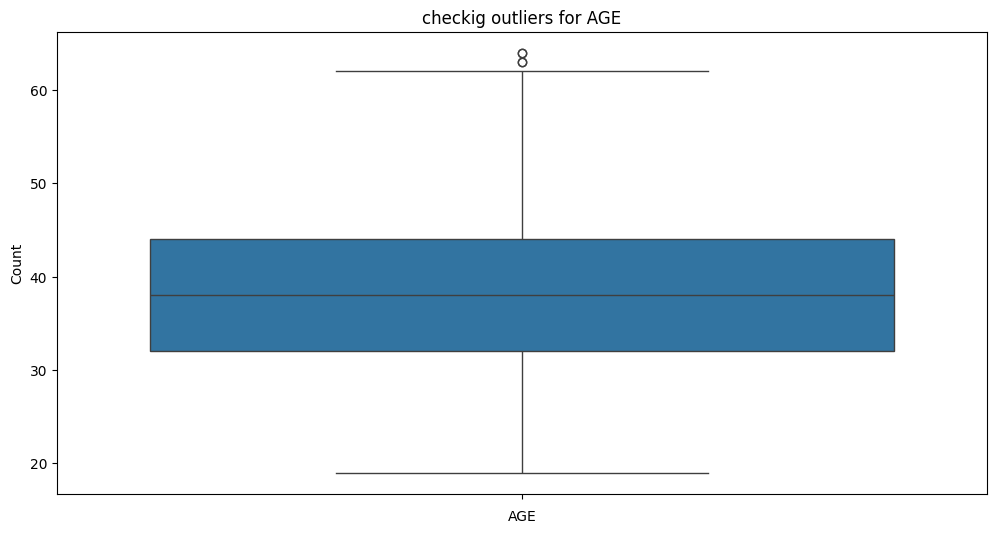

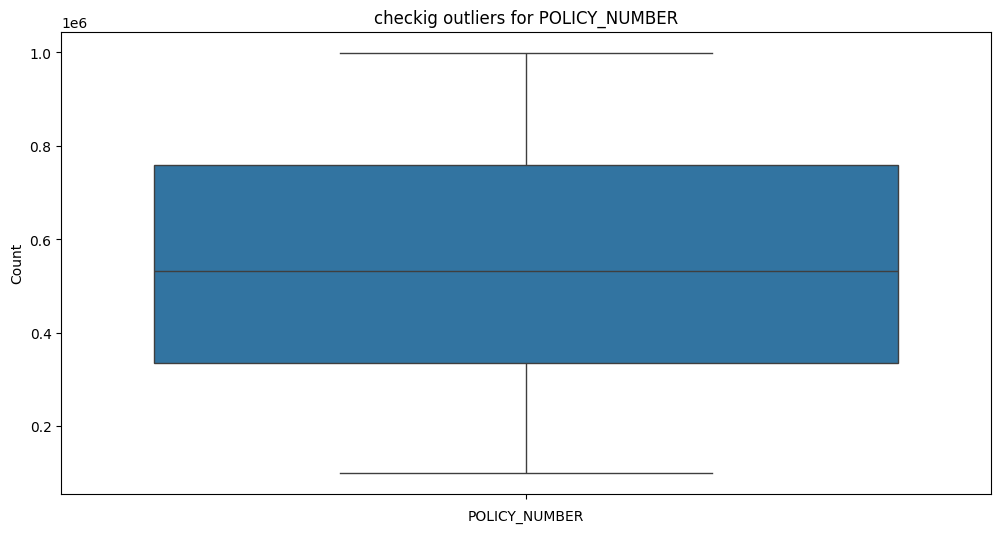

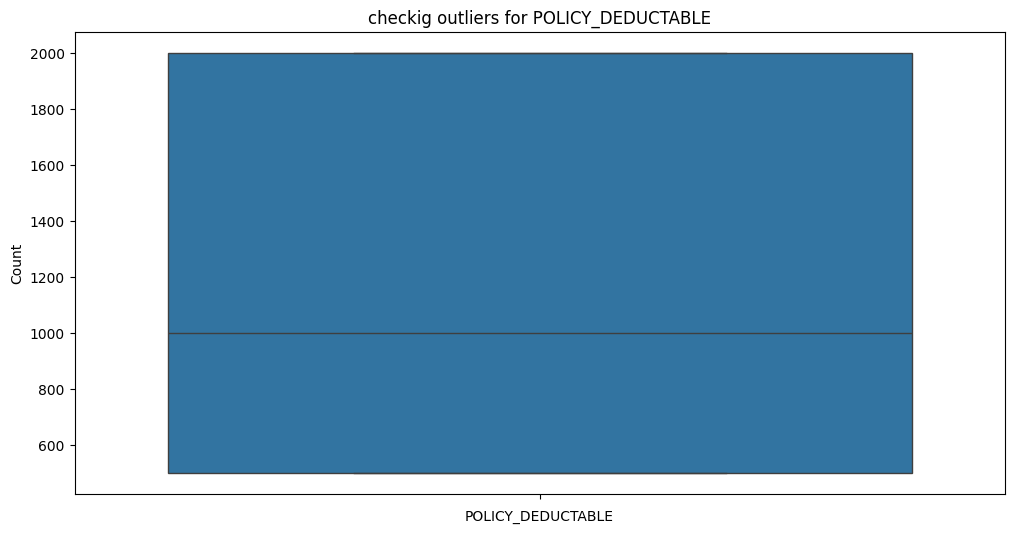

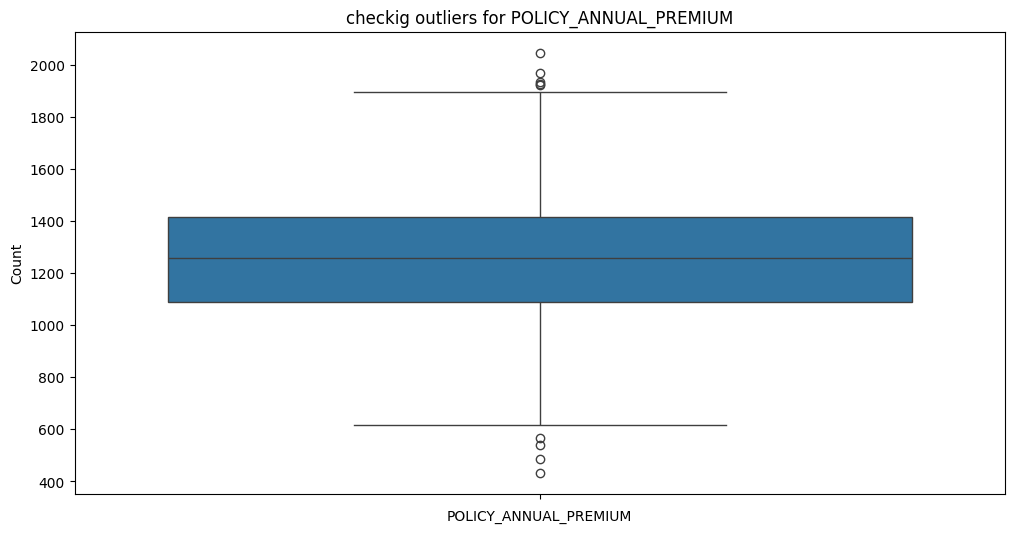

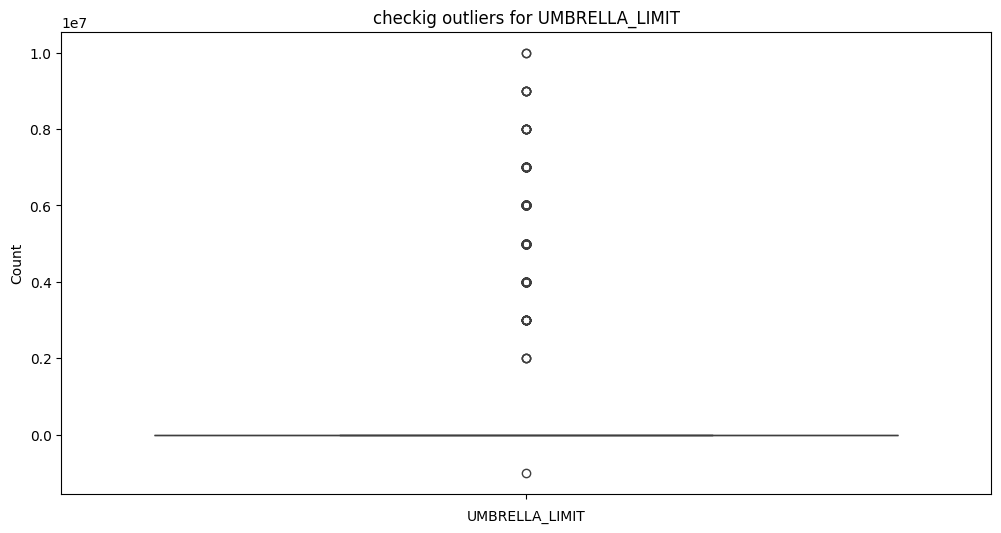

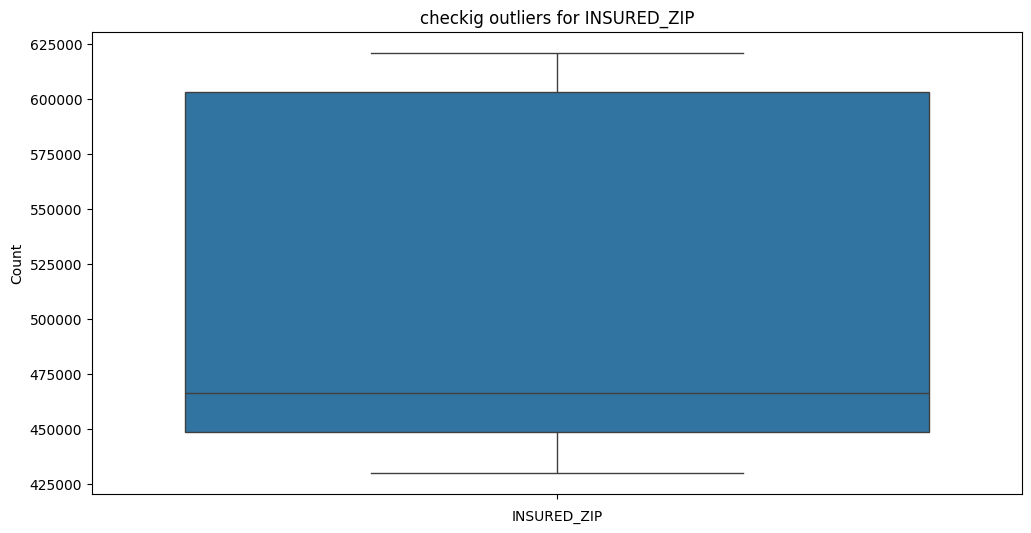

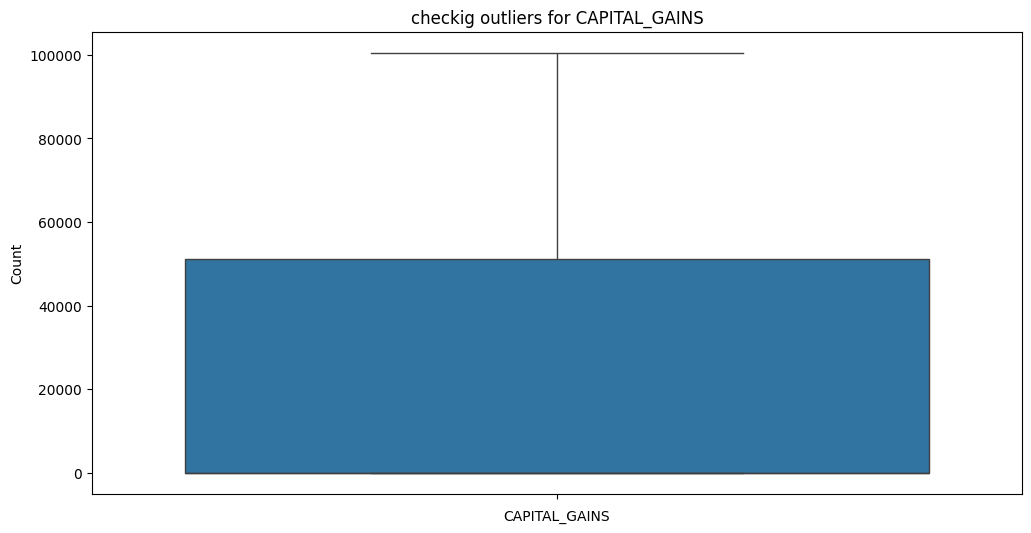

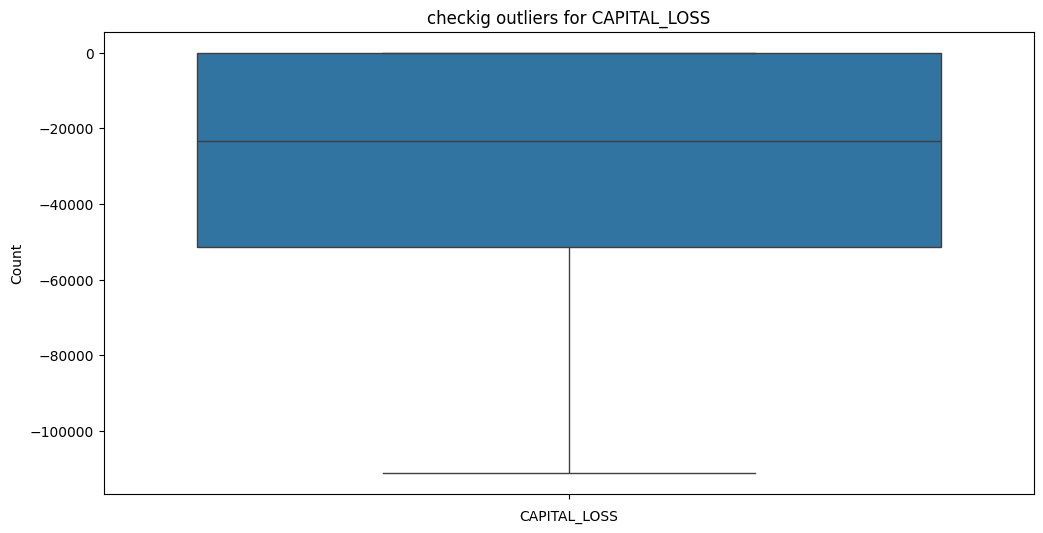

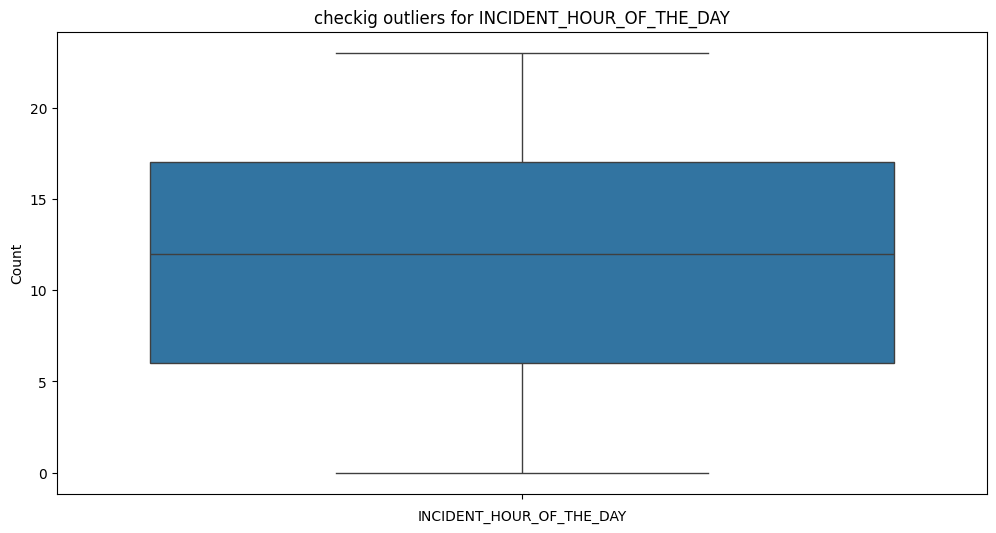

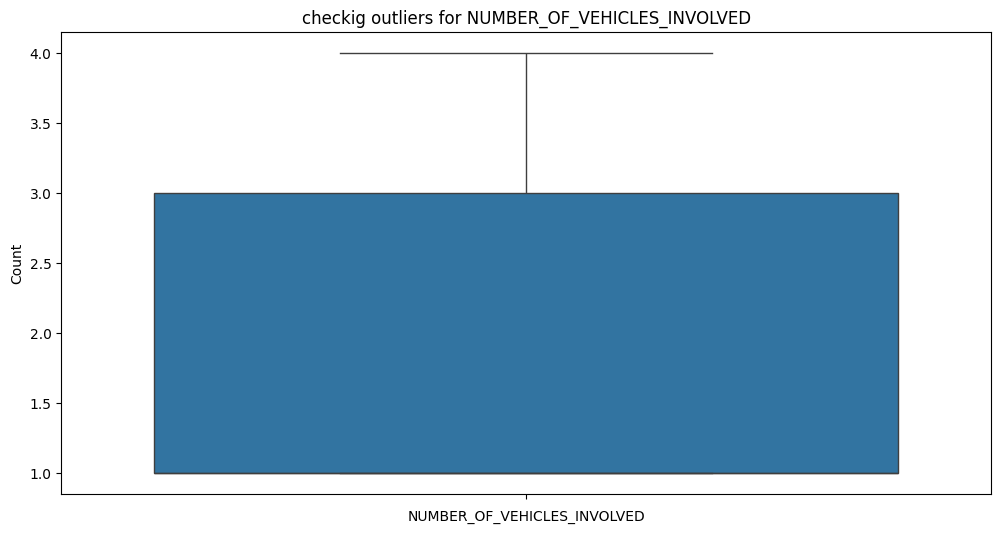

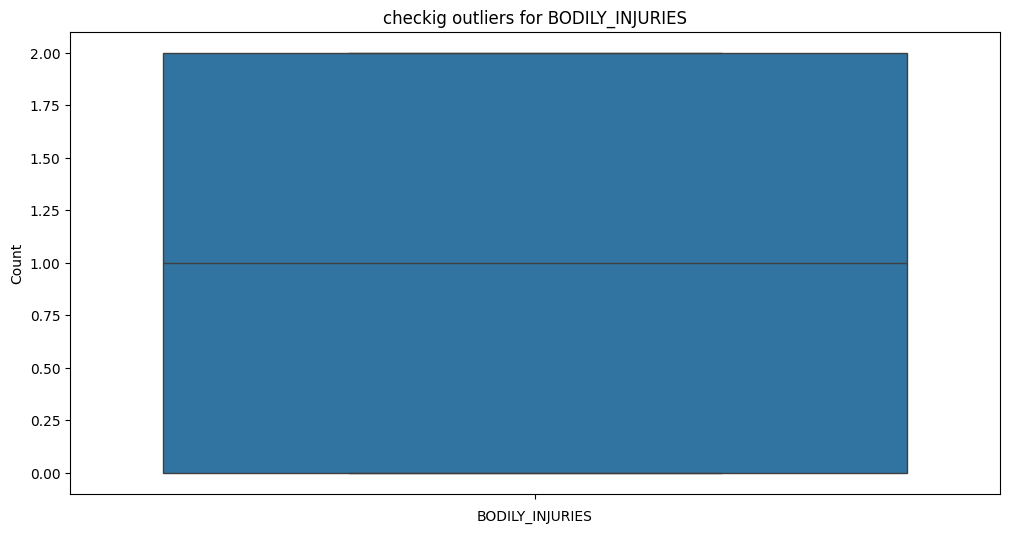

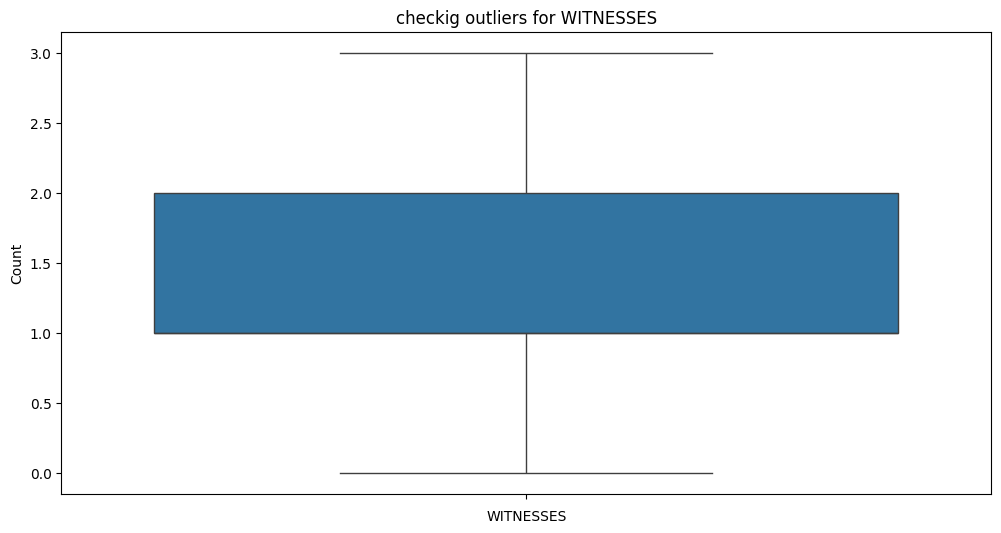

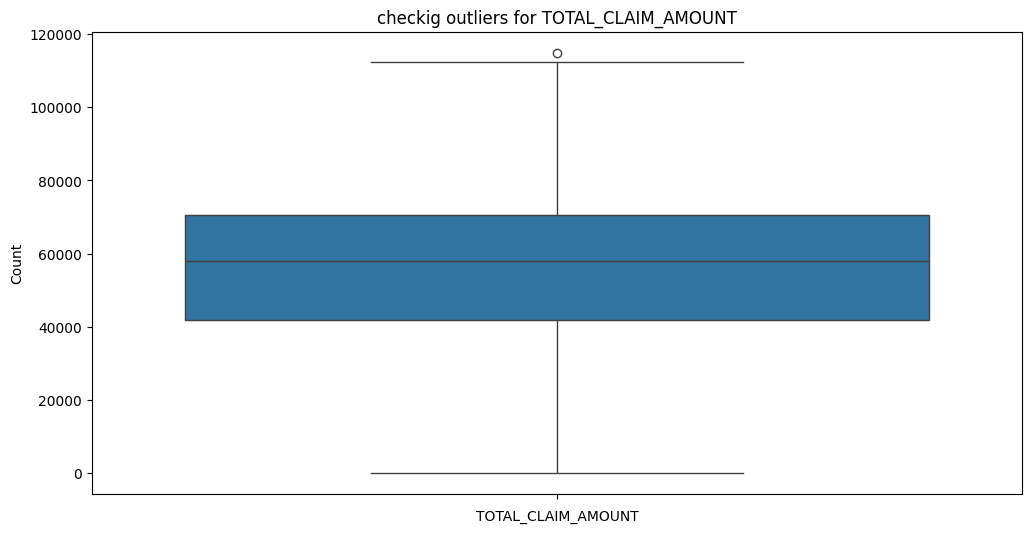

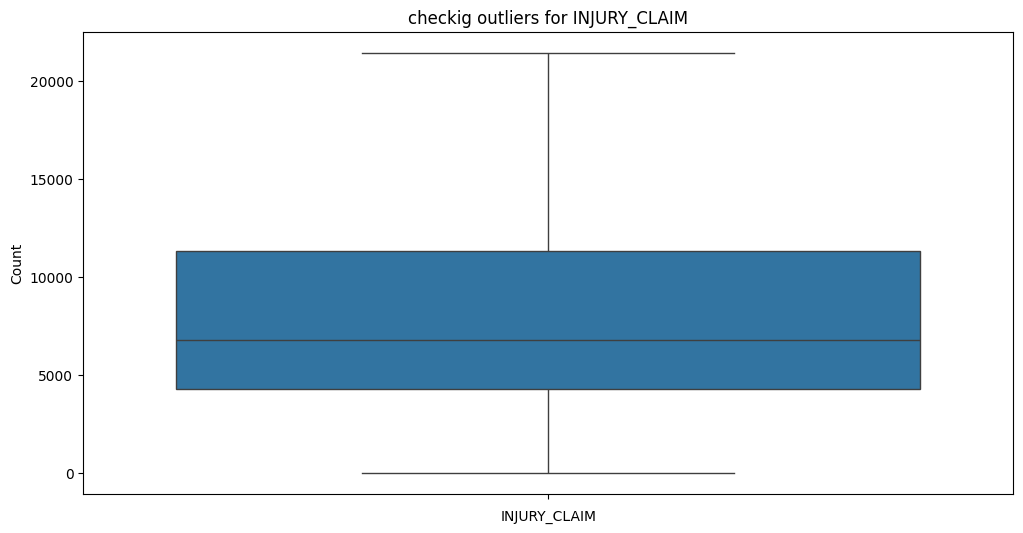

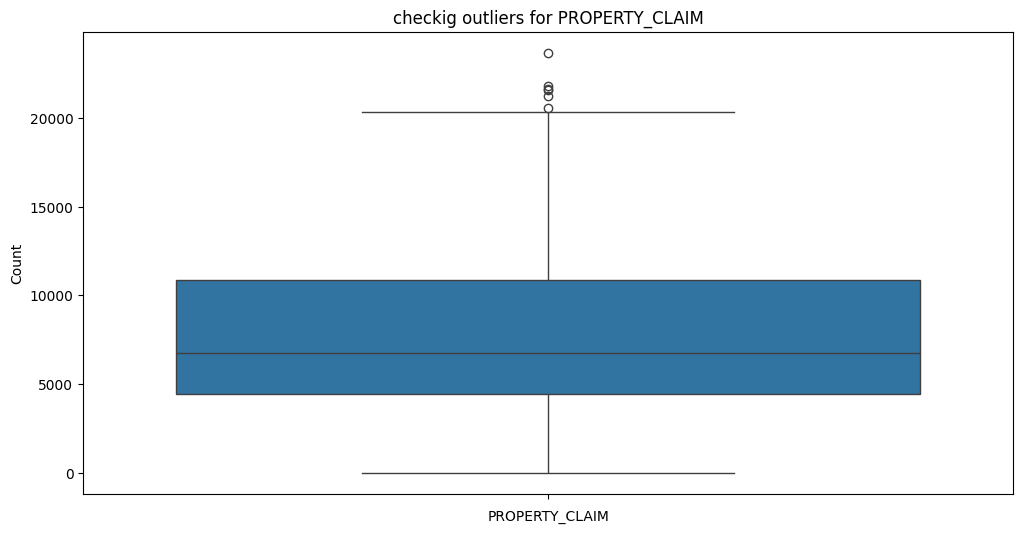

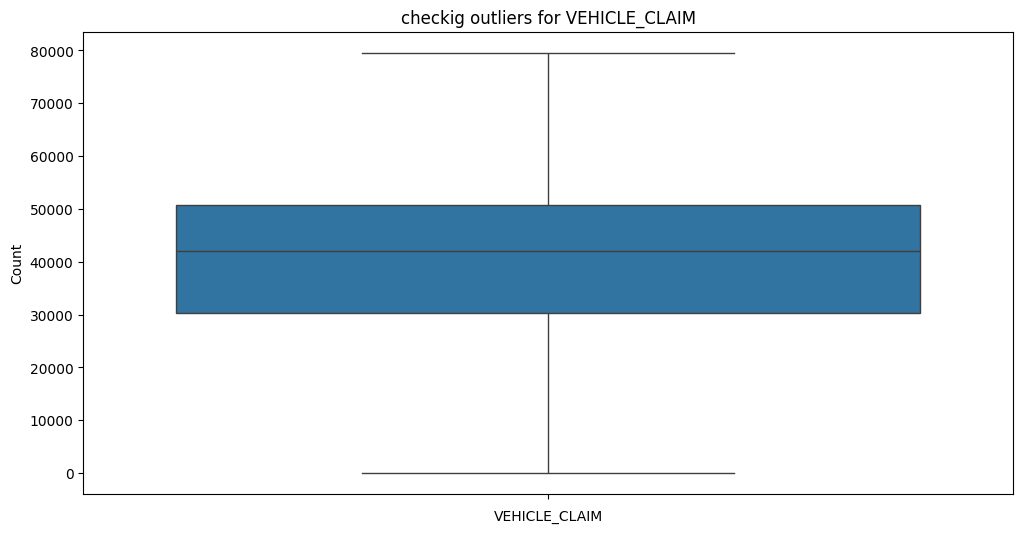

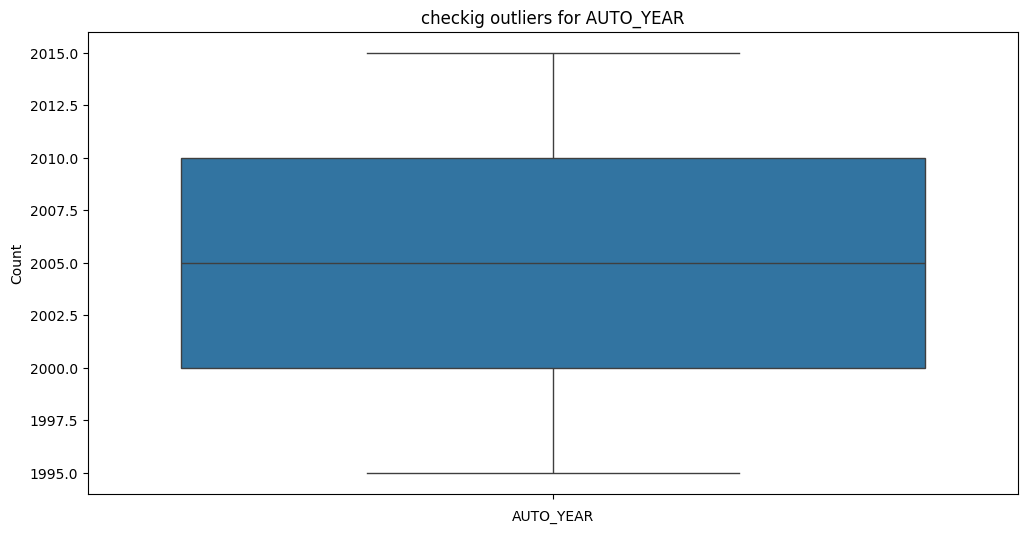

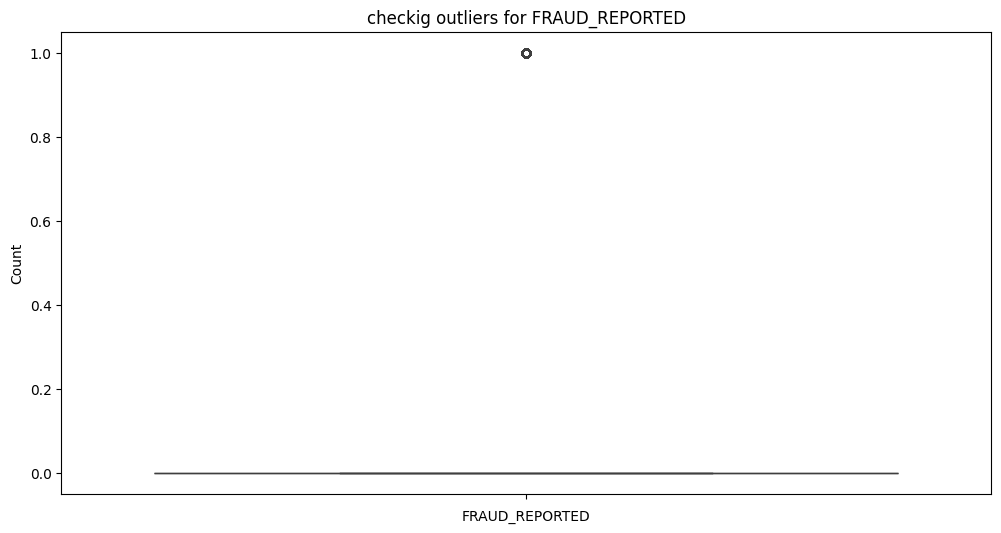

In [191]:
for i in df.columns:
  if df[i].dtypes != "object":
    plt.figure(figsize = (12,6))
    sns.boxplot(df[i])
    plt.title(f"checkig outliers for {i}")
    plt.xlabel(i)
    plt.ylabel("Count")
    plt.show()

In [192]:
col = ["AGE","POLICY_ANNUAL_PREMIUM", "UMBRELLA_LIMIT", "TOTAL_CLAIM_AMOUNT", "PROPERTY_CLAIM"]

In [193]:
#Handling the outliers(iqr method)
for i in col:
  q1 = df[i].quantile(0.25)
  q3 = df[i].quantile(0.75)
  iqr = q3 - q1
  lower_fence = q1 - 1.5*iqr
  upper_fence = q3 + 1.5*iqr
  df = df[(lower_fence <= df[i]) & (upper_fence >= df[i])]

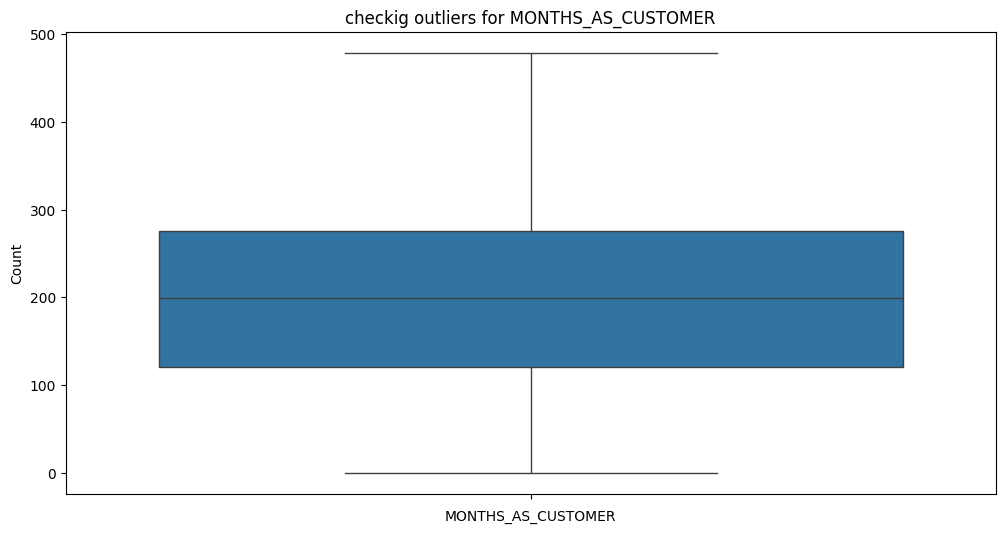

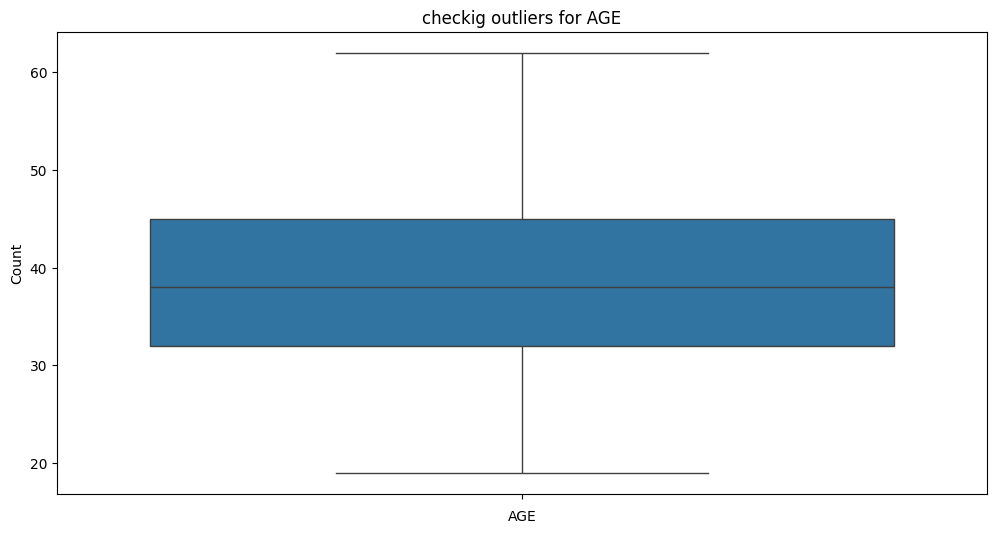

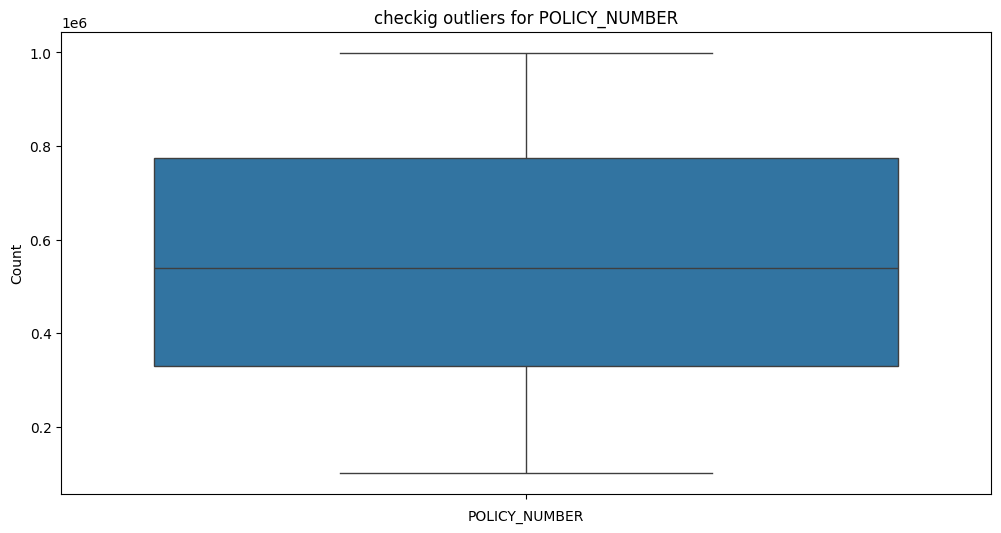

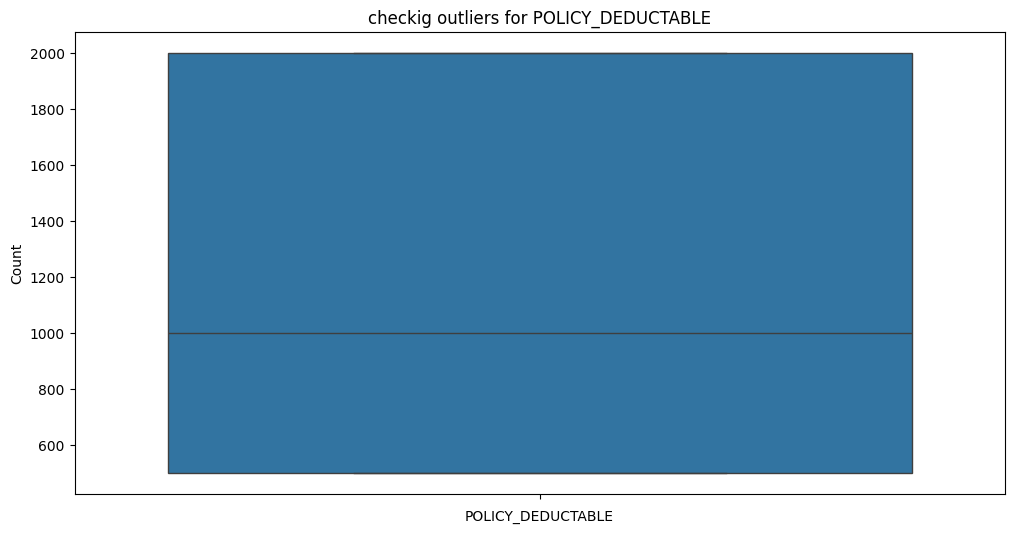

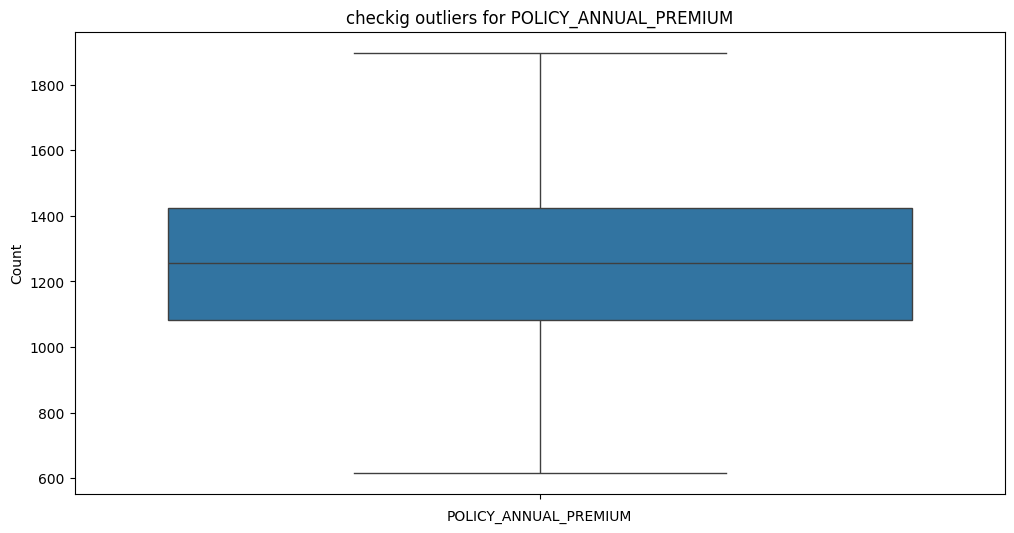

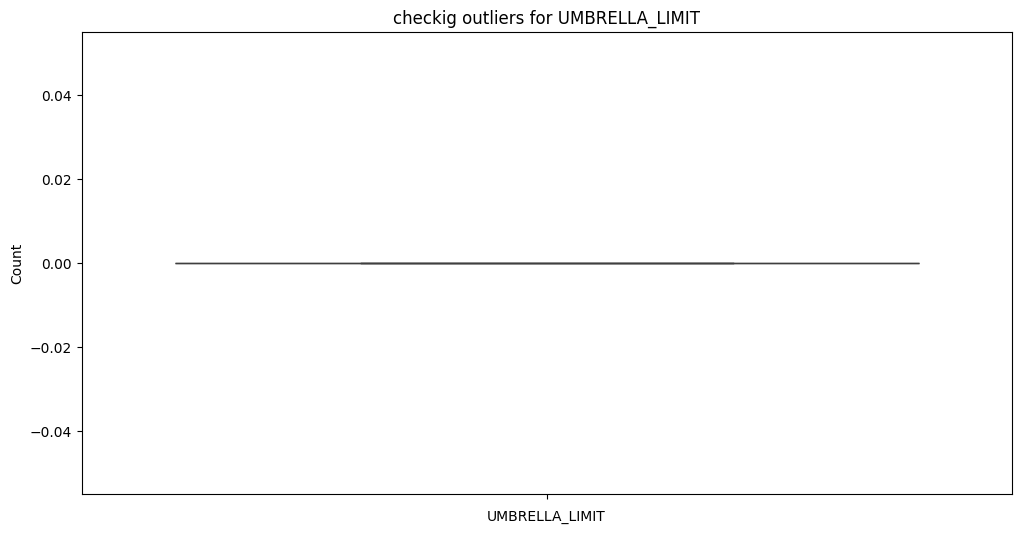

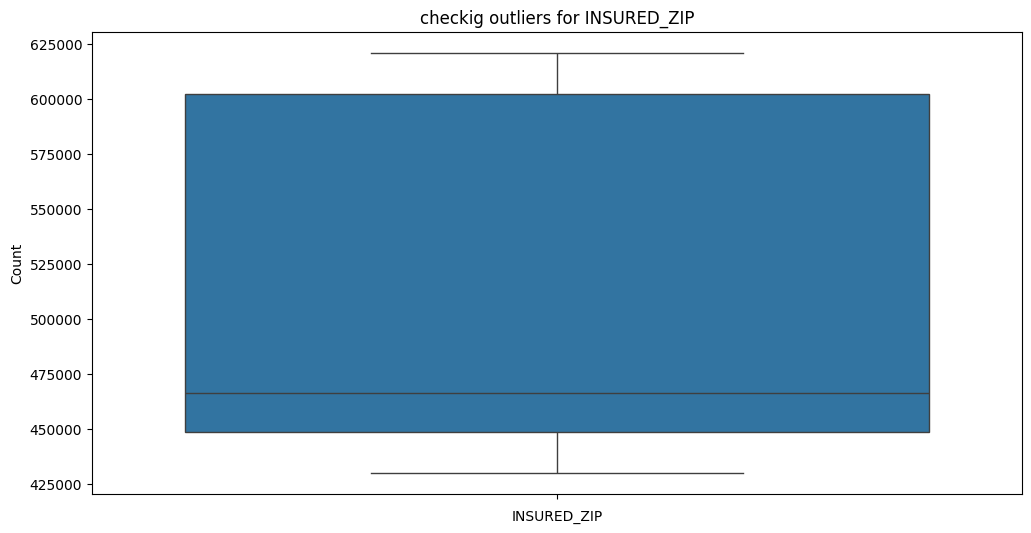

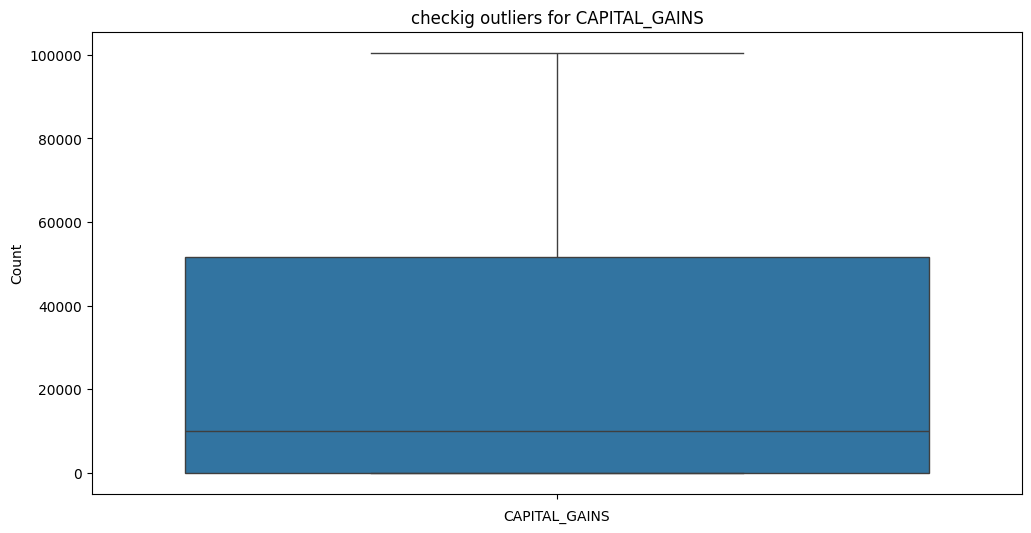

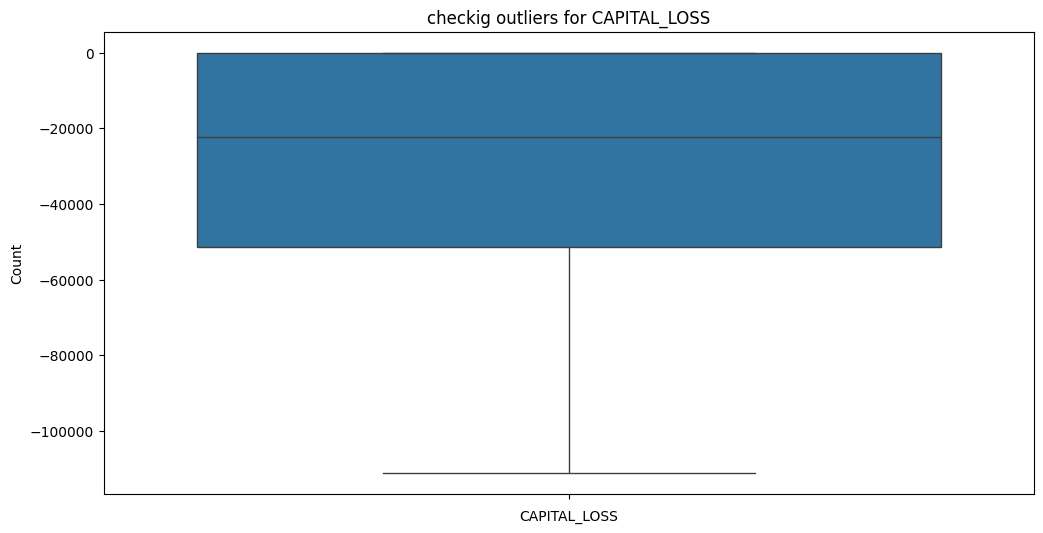

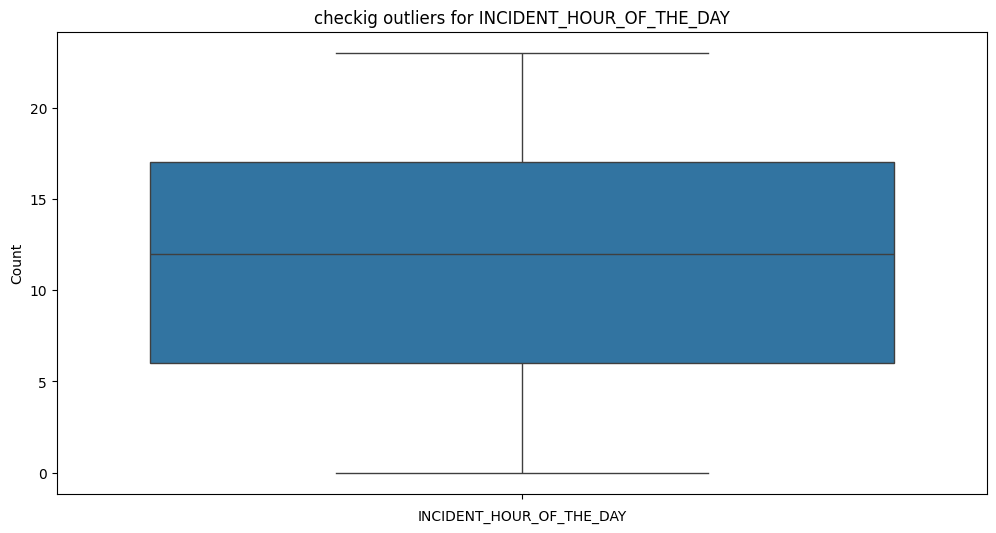

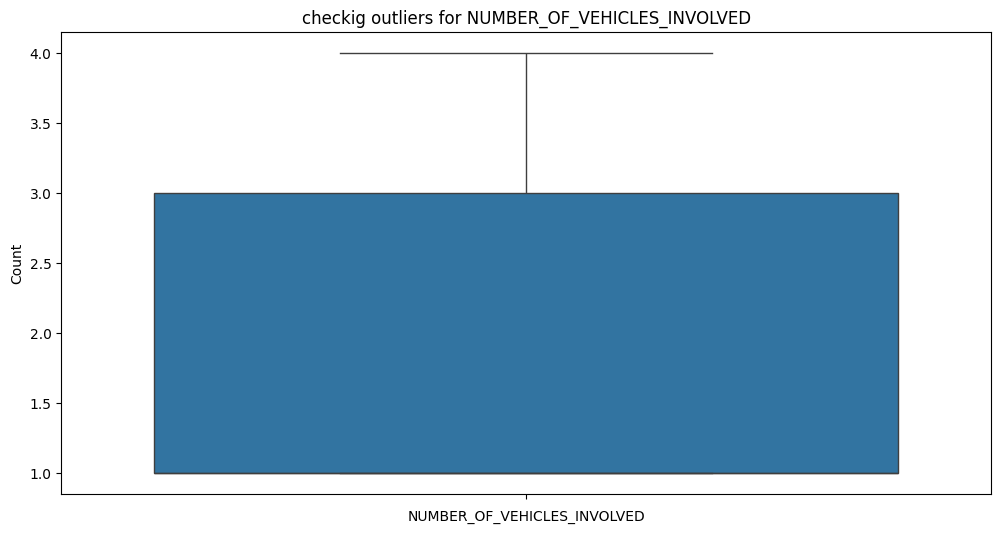

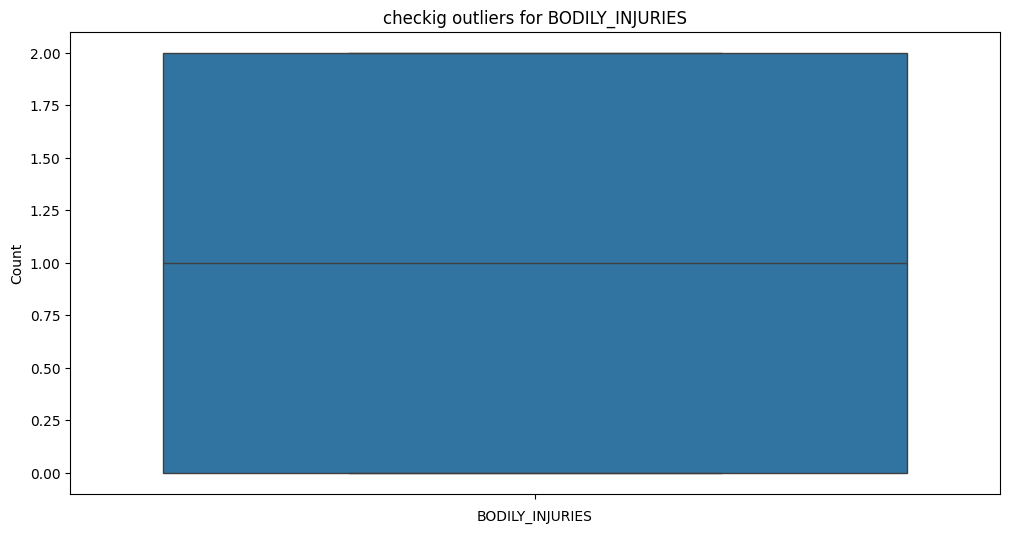

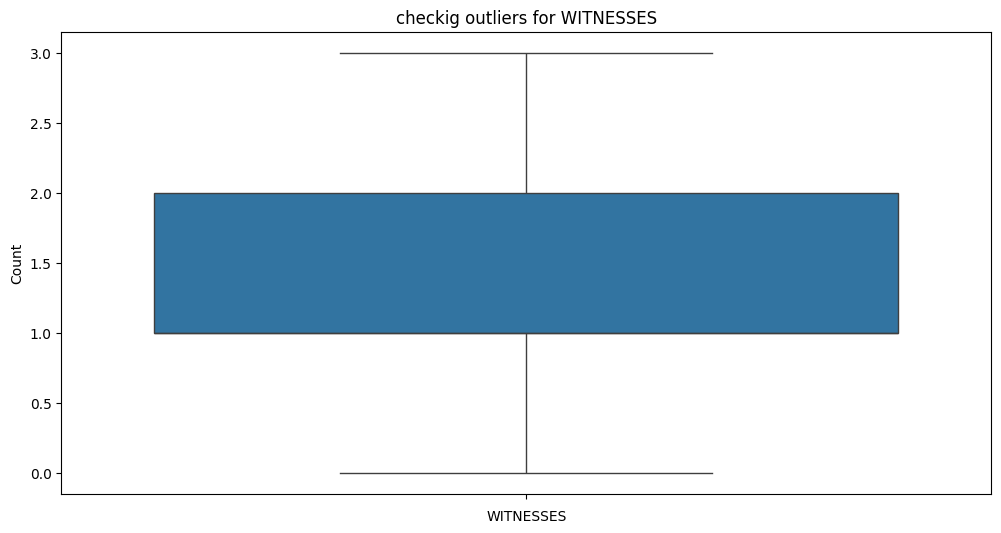

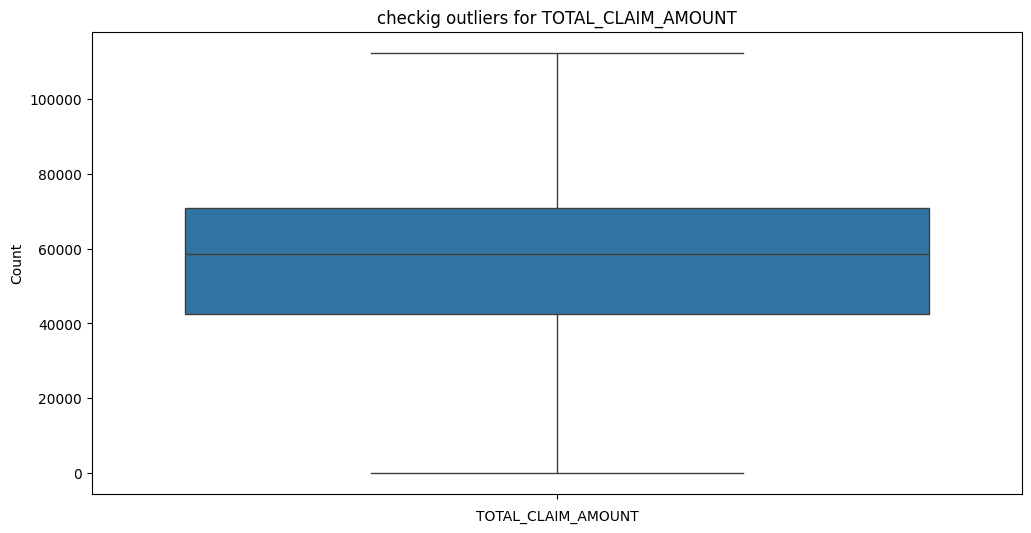

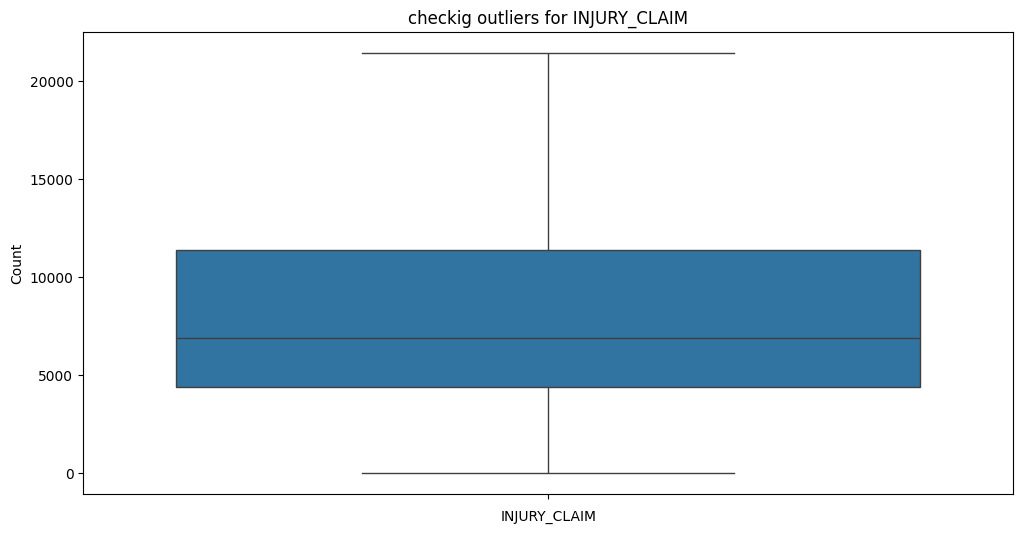

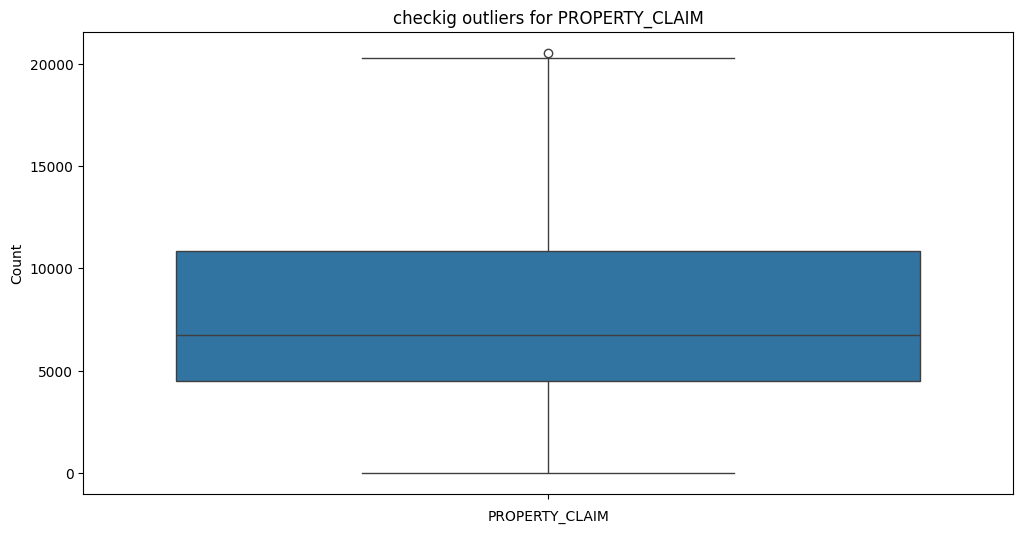

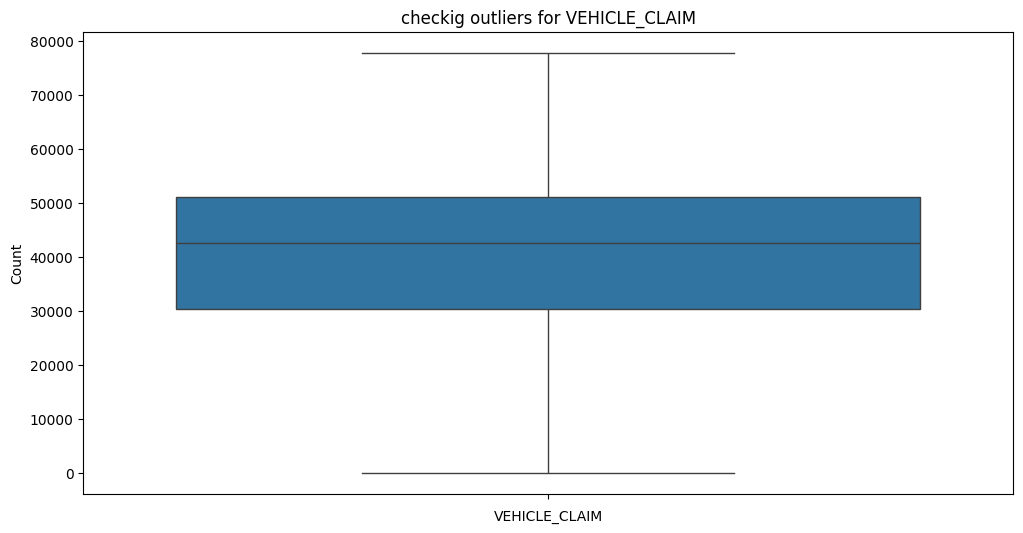

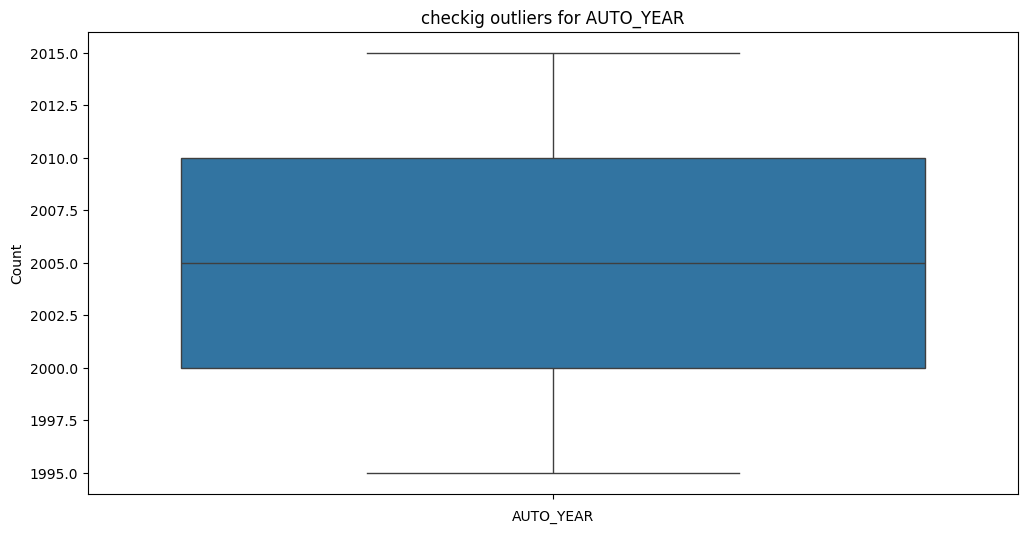

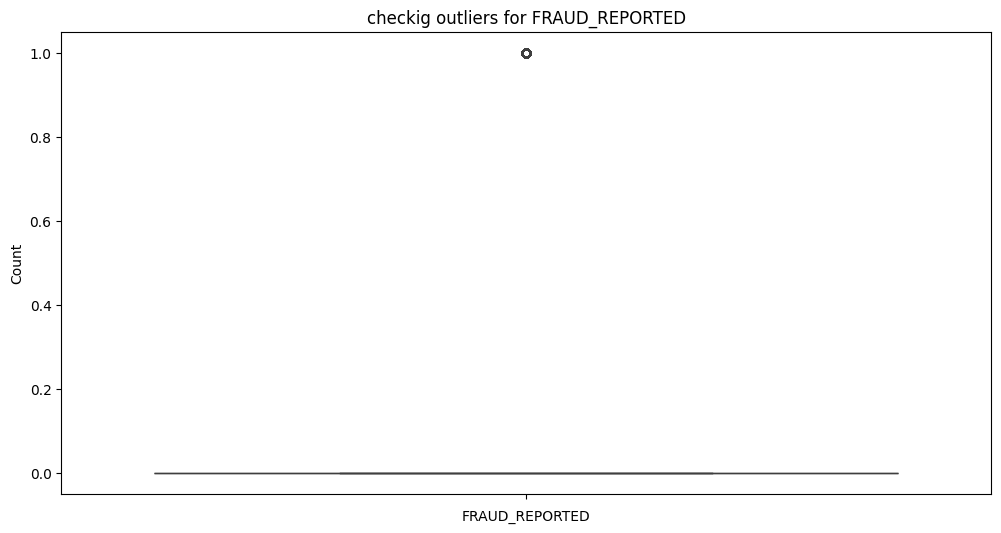

In [194]:
for i in df.columns:
  if df[i].dtypes != "object":
    plt.figure(figsize = (12,6))
    sns.boxplot(df[i])
    plt.title(f"checkig outliers for {i}")
    plt.xlabel(i)
    plt.ylabel("Count")
    plt.show()

In [195]:
df.head()

,MONTHS_AS_CUSTOMER,AGE,POLICY_NUMBER,POLICY_BIND_DATE,POLICY_STATE,POLICY_CSL,POLICY_DEDUCTABLE,POLICY_ANNUAL_PREMIUM,UMBRELLA_LIMIT,INSURED_ZIP,...,WITNESSES,POLICE_REPORT_AVAILABLE,TOTAL_CLAIM_AMOUNT,INJURY_CLAIM,PROPERTY_CLAIM,VEHICLE_CLAIM,AUTO_MAKE,AUTO_MODEL,AUTO_YEAR,FRAUD_REPORTED
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,2,YES,71610,6510,13020,52080,Saab,92x,2004,True
5,256,39,104594,2006-10-12,OH,250/500,1000,1351.10,0,478456,...,2,NO,64100,6410,6410,51280,Saab,95,2003,True
6,137,34,413978,2000-06-04,IN,250/500,1000,1333.35,0,441716,...,0,?,78650,21450,7150,50050,Nissan,Pathfinder,2012,False
7,165,37,429027,1990-02-03,IL,100/300,1000,1137.03,0,603195,...,2,YES,51590,9380,9380,32830,Audi,A5,2015,False
8,27,33,485665,1997-02-05,IL,100/300,500,1442.99,0,601734,...,1,YES,27700,2770,2770,22160,Toyota,Camry,2012,False


In [196]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for i in df.columns:
  if df[i].dtypes == "object" or df[i].dtypes == "boolean":
    df[i] = le.fit_transform(df[i])

In [197]:
df

,MONTHS_AS_CUSTOMER,AGE,POLICY_NUMBER,POLICY_BIND_DATE,POLICY_STATE,POLICY_CSL,POLICY_DEDUCTABLE,POLICY_ANNUAL_PREMIUM,UMBRELLA_LIMIT,INSURED_ZIP,...,WITNESSES,POLICE_REPORT_AVAILABLE,TOTAL_CLAIM_AMOUNT,INJURY_CLAIM,PROPERTY_CLAIM,VEHICLE_CLAIM,AUTO_MAKE,AUTO_MODEL,AUTO_YEAR,FRAUD_REPORTED
0,328,48,521585,741,2,1,1000,1406.91,0,466132,...,2,2,71610,6510,13020,52080,10,1,2004,True
5,256,39,104594,518,2,1,1000,1351.10,0,478456,...,2,1,64100,6410,6410,51280,10,3,2003,True
6,137,34,413978,320,1,1,1000,1333.35,0,441716,...,0,0,78650,21450,7150,50050,9,29,2012,False
7,165,37,429027,3,0,0,1000,1137.03,0,603195,...,2,2,51590,9380,9380,32830,1,5,2015,False
8,27,33,485665,240,0,0,500,1442.99,0,601734,...,1,2,27700,2770,2770,22160,12,9,2012,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
993,124,28,674570,370,2,1,1000,1235.14,0,443567,...,1,0,60200,6020,6020,48160,13,28,2012,False
994,141,30,681486,532,1,2,1000,1347.04,0,430665,...,2,2,6480,540,1080,4860,6,10,1996,False
995,3,38,941851,57,2,2,1000,1310.80,0,431289,...,1,0,87200,17440,8720,61040,6,6,2006,False
996,285,41,186934,713,0,0,1000,1436.79,0,608177,...,3,0,108480,18080,18080,72320,13,28,2015,False


In [198]:
df["FRAUD_REPORTED"].unique()

array([ True, False])

In [199]:
df["FRAUD_REPORTED"] = df["FRAUD_REPORTED"].replace({"True": 1, "False":0})

In [200]:
df["FRAUD_REPORTED"] = df["FRAUD_REPORTED"].astype(int)

In [201]:
df

,MONTHS_AS_CUSTOMER,AGE,POLICY_NUMBER,POLICY_BIND_DATE,POLICY_STATE,POLICY_CSL,POLICY_DEDUCTABLE,POLICY_ANNUAL_PREMIUM,UMBRELLA_LIMIT,INSURED_ZIP,...,WITNESSES,POLICE_REPORT_AVAILABLE,TOTAL_CLAIM_AMOUNT,INJURY_CLAIM,PROPERTY_CLAIM,VEHICLE_CLAIM,AUTO_MAKE,AUTO_MODEL,AUTO_YEAR,FRAUD_REPORTED
0,328,48,521585,741,2,1,1000,1406.91,0,466132,...,2,2,71610,6510,13020,52080,10,1,2004,1
5,256,39,104594,518,2,1,1000,1351.10,0,478456,...,2,1,64100,6410,6410,51280,10,3,2003,1
6,137,34,413978,320,1,1,1000,1333.35,0,441716,...,0,0,78650,21450,7150,50050,9,29,2012,0
7,165,37,429027,3,0,0,1000,1137.03,0,603195,...,2,2,51590,9380,9380,32830,1,5,2015,0
8,27,33,485665,240,0,0,500,1442.99,0,601734,...,1,2,27700,2770,2770,22160,12,9,2012,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
993,124,28,674570,370,2,1,1000,1235.14,0,443567,...,1,0,60200,6020,6020,48160,13,28,2012,0
994,141,30,681486,532,1,2,1000,1347.04,0,430665,...,2,2,6480,540,1080,4860,6,10,1996,0
995,3,38,941851,57,2,2,1000,1310.80,0,431289,...,1,0,87200,17440,8720,61040,6,6,2006,0
996,285,41,186934,713,0,0,1000,1436.79,0,608177,...,3,0,108480,18080,18080,72320,13,28,2015,0


In [202]:
x = df.iloc[:,:-1]
y = df[["FRAUD_REPORTED"]]

In [203]:
from sklearn.model_selection import train_test_split
x_train , x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [204]:
x_train

,MONTHS_AS_CUSTOMER,AGE,POLICY_NUMBER,POLICY_BIND_DATE,POLICY_STATE,POLICY_CSL,POLICY_DEDUCTABLE,POLICY_ANNUAL_PREMIUM,UMBRELLA_LIMIT,INSURED_ZIP,...,BODILY_INJURIES,WITNESSES,POLICE_REPORT_AVAILABLE,TOTAL_CLAIM_AMOUNT,INJURY_CLAIM,PROPERTY_CLAIM,VEHICLE_CLAIM,AUTO_MAKE,AUTO_MODEL,AUTO_YEAR
861,212,40,489618,410,0,2,1000,1524.45,0,452438,...,0,2,2,82400,8240,8240,65920,9,29,2006
177,261,45,249048,471,0,1,1000,1254.18,0,457555,...,0,1,0,62590,11380,11380,39830,13,20,2003
317,275,45,403737,78,1,2,2000,1447.77,0,605756,...,1,1,0,64320,5360,10720,48240,0,23,1998
75,120,35,116700,340,2,0,1000,1425.54,0,475847,...,2,0,1,51210,11380,5690,34140,5,16,2010
989,22,21,550127,539,1,1,1000,1248.05,0,443550,...,1,2,0,53280,5920,0,47360,3,25,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,239,42,246882,303,0,0,1000,969.50,0,464839,...,0,0,0,5600,700,700,4200,1,4,2007
142,122,34,139872,507,1,1,1000,1220.71,0,603639,...,2,1,2,8190,1890,1260,5040,3,32,2013
357,110,28,435784,703,2,1,1000,1573.93,0,461919,...,0,2,0,65040,10840,10840,43360,11,19,2010
565,392,50,556415,63,2,0,2000,1108.97,0,431496,...,2,2,2,108030,16620,16620,74790,10,1,2002


In [205]:
from sklearn.tree import DecisionTreeClassifier
dc = DecisionTreeClassifier(criterion="gini")
dc.fit(x_train, y_train)
y_pred = dc.predict(x_test)

In [206]:
from sklearn.metrics import accuracy_score
print("Performance of my model:", accuracy_score(y_test, y_pred)*100)

Performance of my model: 74.52229299363057


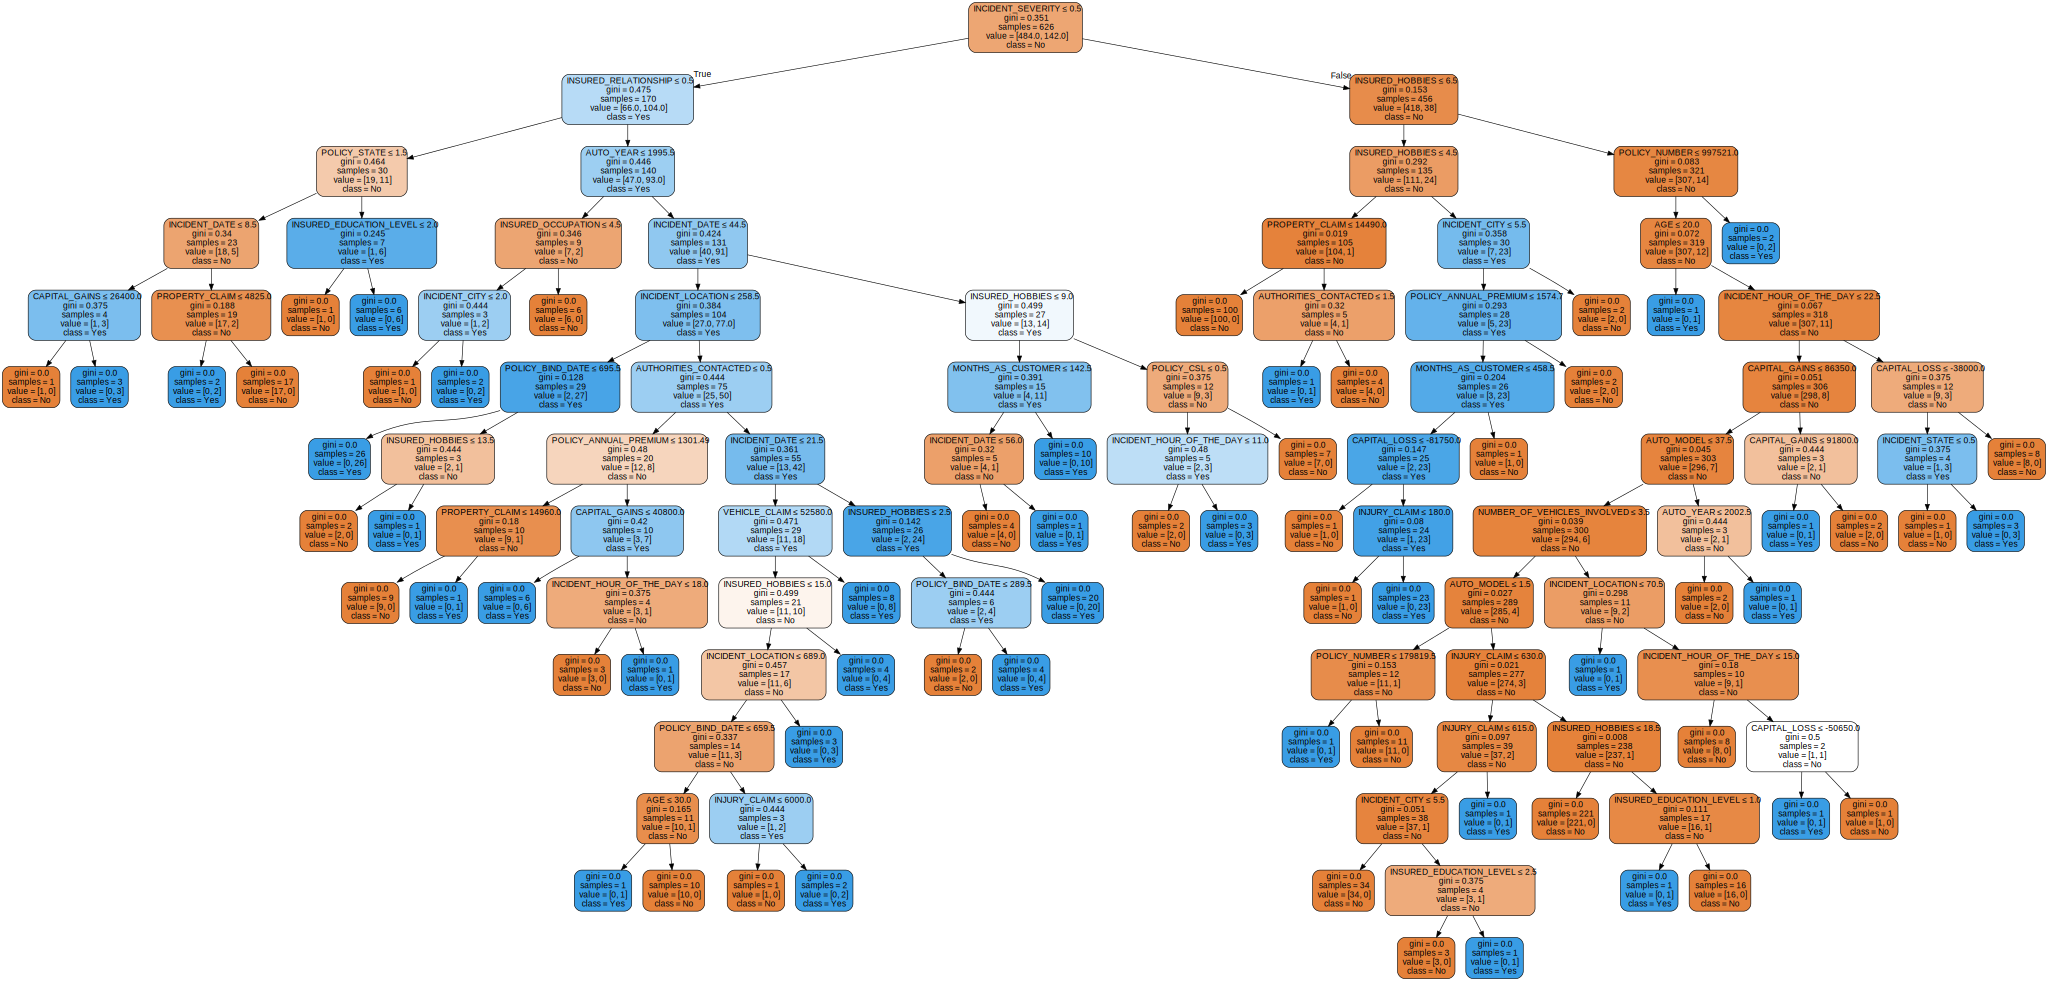

In [207]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    dc,
    out_file=None,
    feature_names=x.columns,
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph